In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

# Exploratory Data Analysis

## Load the data

In [2]:
df_salaries = pd.read_csv('./datasets/salaries_dataset.csv')
df_salaries.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   months_with_the_company  1000 non-null   int64  
 1   job_level                1000 non-null   int64  
 2   salary_in_reais          1000 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 23.6 KB


In [3]:
# Creating a df for EDA & Bucketing
df_salaries_eda = df_salaries.copy()
df_salaries_bucketing = df_salaries.copy()

## Visualize the data

In [4]:
df_salaries_eda.head(10)

,months_with_the_company,job_level,salary_in_reais
0,50,1,2288.13
1,49,4,2389.84
2,39,10,2158.73
3,51,1,2341.06
4,62,7,3584.20
5,105,10,12102.18
6,80,3,5723.35
7,85,2,6424.92
8,66,5,3916.18
9,73,5,4751.79


In [5]:
df_salaries_eda.describe()

,months_with_the_company,job_level,salary_in_reais
count,1000.000000,1000.000000,1000.000000
mean,59.712000,5.467000,5093.726110
std,34.027679,2.889509,4536.168857
min,1.000000,1.000000,538.560000
25%,30.750000,3.000000,1537.477500
50%,60.000000,6.000000,3237.920000
75%,89.000000,8.000000,7436.680000
max,120.000000,10.000000,18923.230000


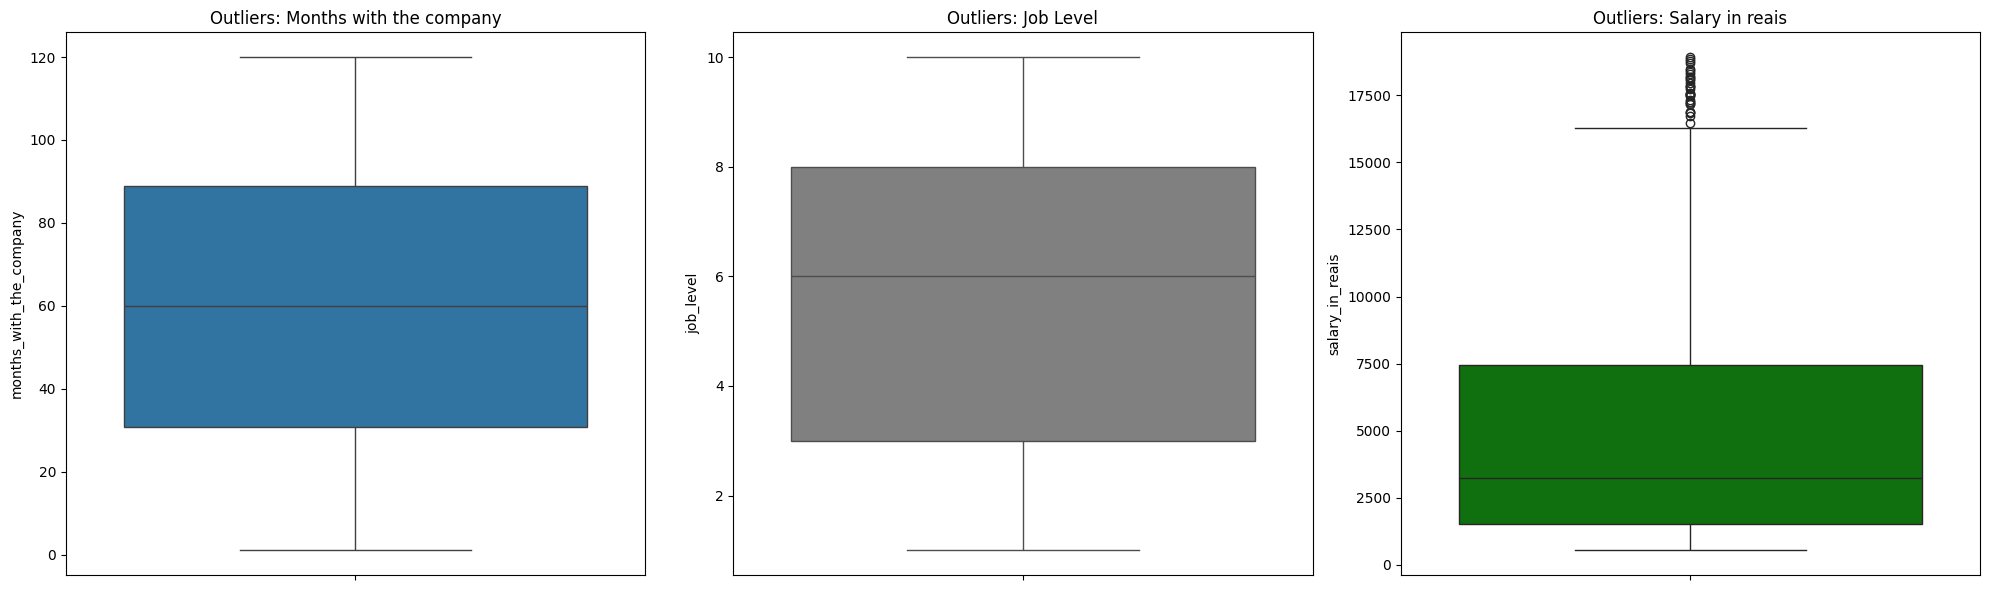

In [6]:
# Checking for outliers
# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# First plot on the left (index 0)
sns.boxplot(data=df_salaries_eda, y='months_with_the_company', ax=axes[0])
axes[0].set_title("Outliers: Months with the company")

# Second plot (index 1)
sns.boxplot(data=df_salaries_eda, y='job_level', ax=axes[1], color='gray')
axes[1].set_title("Outliers: Job Level")

# Third plot (index 2)
sns.boxplot(data=df_salaries_eda, y='salary_in_reais', ax=axes[2], color='green')
axes[2].set_title("Outliers: Salary in reais")

plt.tight_layout() # Adjusts spacing to prevent overlap
plt.show()

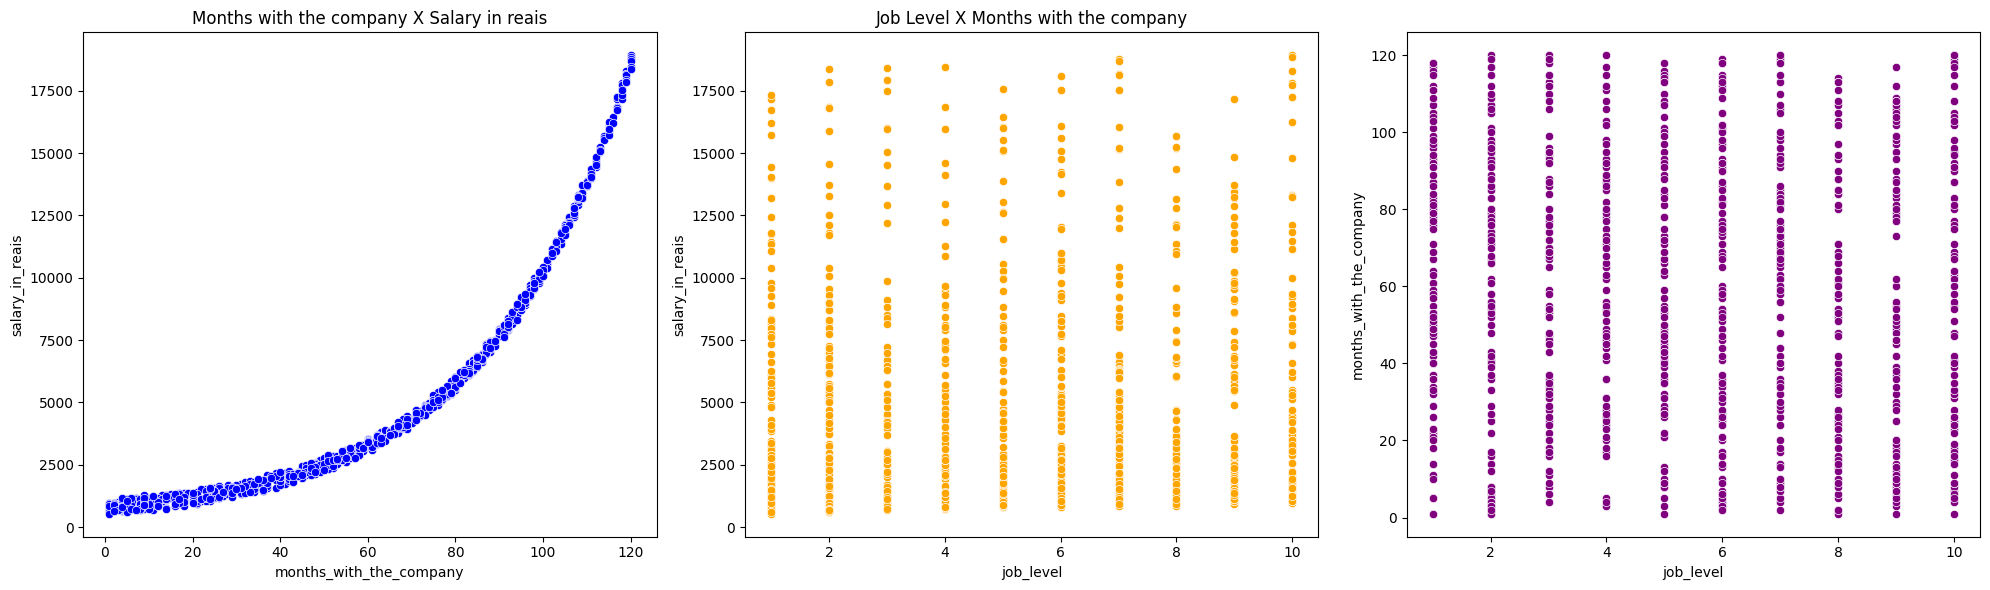

In [7]:
# Crossing the numeric variables with the salary
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# First plot on the left (index 0)
sns.scatterplot(data=df_salaries_eda, x='months_with_the_company', y='salary_in_reais', ax=axes[0], color='blue')
axes[0].set_title("Months with the company X Salary in reais")

# Second plot (index 1)
sns.scatterplot(data=df_salaries_eda, x='job_level', y='salary_in_reais', ax=axes[1], color='orange')
axes[1].set_title("Job Level X Salary in reais")

# Third plot (index 2)
sns.scatterplot(data=df_salaries_eda, x='job_level', y='months_with_the_company', ax=axes[2], color='purple')
axes[1].set_title("Job Level X Months with the company")

plt.tight_layout() # Adjusts spacing to prevent overlap
plt.show()

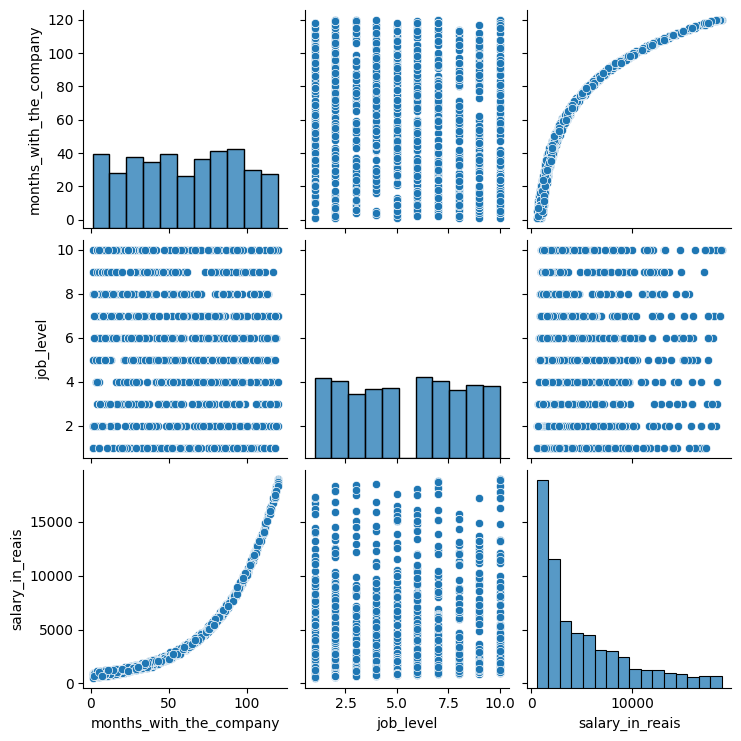

In [8]:
sns.pairplot(df_salaries_eda)

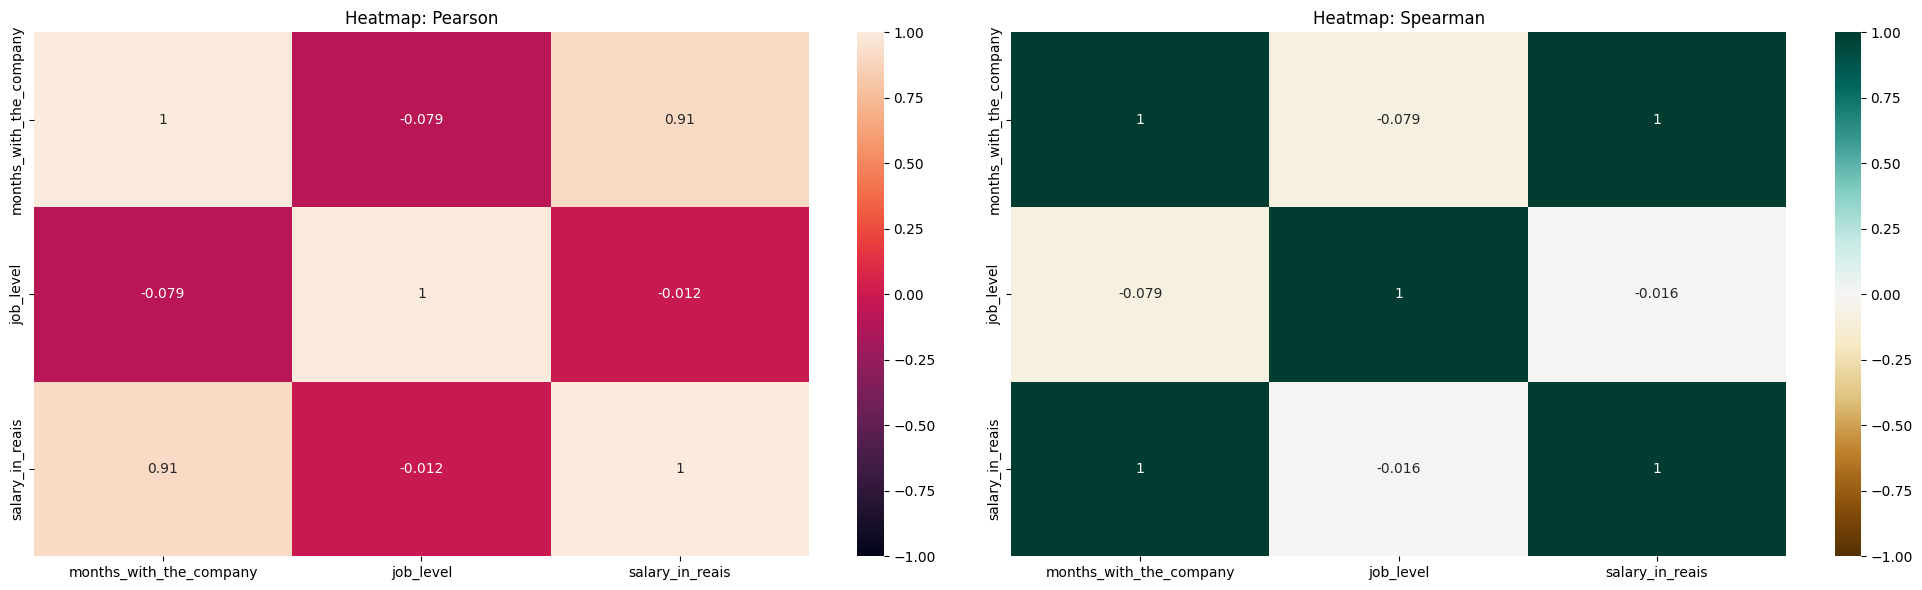

In [9]:
# Checking for the correlation
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# First plot on the left (index 0)
sns.heatmap(df_salaries_eda.corr(), vmax=1, vmin=-1, annot=True, ax=axes[0], color='blue')
axes[0].set_title("Heatmap: Pearson")

# Second plot (index 1)
sns.heatmap(df_salaries_eda.corr('spearman'), vmax=1, vmin=-1, cmap='BrBG', annot=True, ax=axes[1], color='orange')
axes[1].set_title("Heatmap: Spearman")

plt.tight_layout() # Adjusts spacing to prevent overlap
plt.show()

In [10]:
bins_months_in_company = [0, 20, 40, 60, 80, 100, 120, 140]
labels_months_in_company = ['0-19', '20-39', '40-59', '60-79', '80-99', '100-119','120-139']

df_salaries_bucketing['scale_months'] = pd.cut(
                                                x=df_salaries_bucketing.months_with_the_company, 
                                                bins=bins_months_in_company,
                                                labels=labels_months_in_company,
                                                include_lowest=True
                                            )

df_salaries_bucketing.head(10)

,months_with_the_company,job_level,salary_in_reais,scale_months
0,50,1,2288.13,40-59
1,49,4,2389.84,40-59
2,39,10,2158.73,20-39
3,51,1,2341.06,40-59
4,62,7,3584.20,60-79
5,105,10,12102.18,100-119
6,80,3,5723.35,60-79
7,85,2,6424.92,80-99
8,66,5,3916.18,60-79
9,73,5,4751.79,60-79


<Axes: xlabel='scale_months', ylabel='salary_in_reais'>

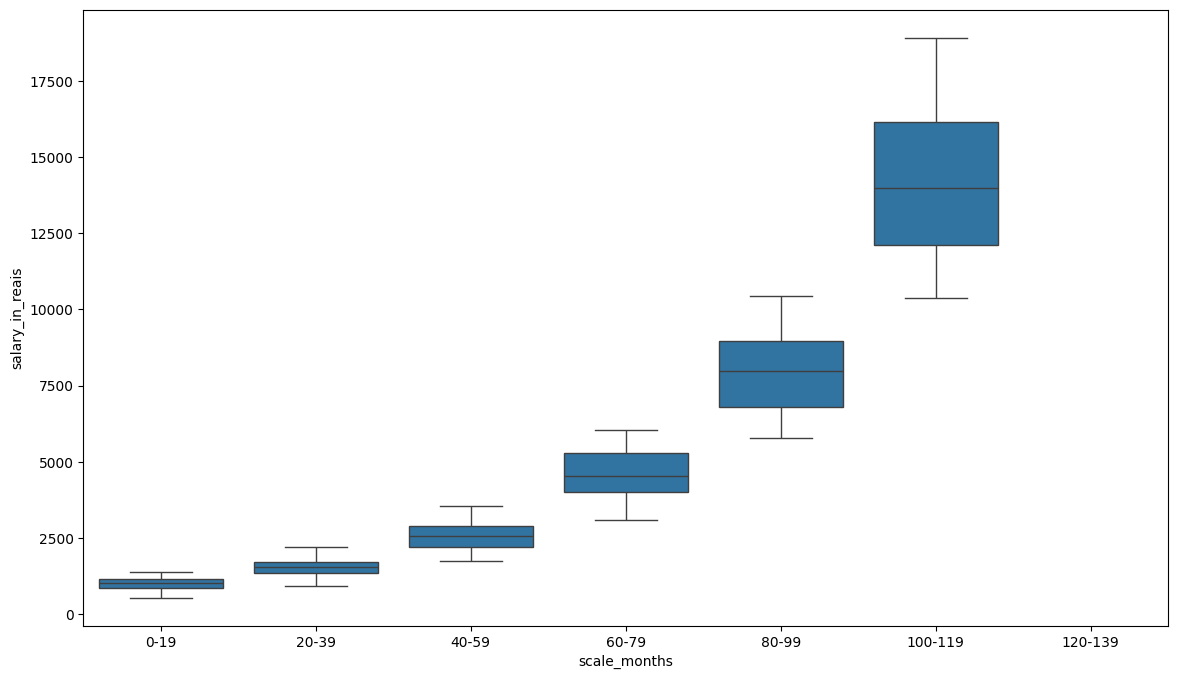

In [11]:
plt.figure(figsize=(14,8))
sns.boxplot(df_salaries_bucketing, x='scale_months', y='salary_in_reais')

# Models Training & Validation

In [18]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, root_mean_squared_error

import numpy as np

## Linear Regression

### Training

In [14]:
# Creating the dataset of Train and Test
X = df_salaries.drop(columns='salary_in_reais')
y = df_salaries.salary_in_reais

In [15]:
# Split using Kfold with 5 folders
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [16]:
kf

KFold(n_splits=5, random_state=42, shuffle=True)

In [20]:
kf.split(X)

<generator object _BaseKFold.split at 0x0000029D2EE23890>

In [25]:
# Pipeline
# Padronize numeric variables
numeric_columns = ['months_with_the_company', 'job_level']

# Transformer for the columns
transformer_numerics = Pipeline(
    steps=[
        ('scaler', StandardScaler())
    ]
)

# Creating the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', transformer_numerics, numeric_columns)
    ]
)

# Creating the main pipeline = Pre processing + training
model_regr = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ]
)

# Store RMSE Train and Test
rsme_scores_fold_train = []
rsme_scores_fold_test = []

# Store R2 Score from test
r2_score_fold_test = []

# Store residues
residues = []

# Store Predictions
y_pred_total = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Train the model with the train set
    model_regr.fit(X_train, y_train)

    # Making predictions with the train e test sets
    y_train_pred = model_regr.predict(X_train)
    y_test_pred = model_regr.predict(X_test)

    # Calculating the metrics for the sets
    rmse_train = root_mean_squared_error(y_train, y_train_pred)
    rmse_test = root_mean_squared_error(y_test, y_test_pred)
    r2score_test = r2_score(y_test, y_test_pred)
    residues_test = np.array(y_test - y_test_pred)

    # Storing the metrics data on lists
    rsme_scores_fold_train.append(rmse_train)
    rsme_scores_fold_test.append(rmse_test)
    r2_score_fold_test.append(r2score_test)
    residues.append(residues_test)
    y_pred_total.append(y_test_pred)


rmse_train_final = np.mean(rsme_scores_fold_train)
rmse_test_final = np.mean(rsme_scores_fold_test)
r2_score_test_final = np.mean(r2_score_fold_test)

percentual_final_rmse = ((rmse_test_final - rmse_train_final) / rmse_train_final) * 100

residues = np.array(residues).reshape(-1)

y_pred_total = np.array(y_pred_total).reshape(-1)

### Model Validation

In [ ]:
# Metrics
print(f'RMSE Train: {rmse_train_final}')
print(f'RMSE Test: {rmse_test_final}')
print(f'% dif. RMSE Train and Test: {percentual_final_rmse}\n')

print(f'R2-Score Test: {r2_score_test_final}')


RMSE Train: 1882.386843341482
RMSE Test: 1888.5627379751618
% dif. RMSE Train and Test: 0.32808849336816975

R2-Score Test: 0.8257851479748144


In [ ]:
# Residues analysis
# Transforming the residues to standard scale
from scipy.stats import zscore
residues_std = zscore(residues)

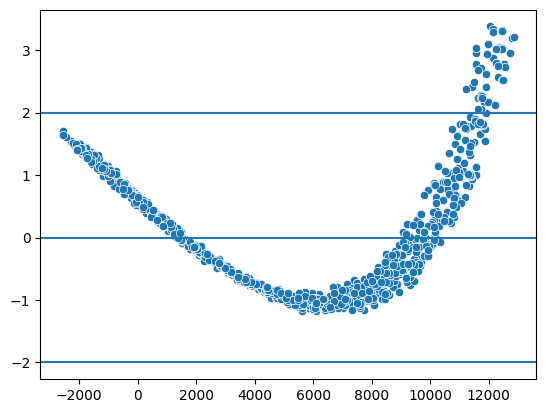

In [29]:
# Checking the linearity from residues: being between -2 and 2
# Checking homoscedasticity: values around the line without tendence or shape

sns.scatterplot(x=y_pred_total, y=residues_std)
plt.axhline(y=0)
plt.axhline(y=-2)
plt.axhline(y=2)

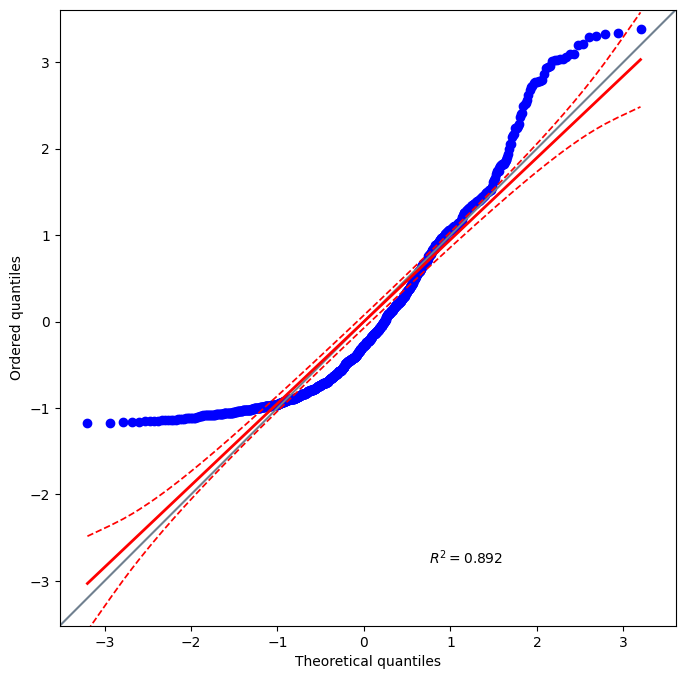

In [33]:
# Check if the residues follow a normal distribuition
# QQ plot 

import pingouin as pg 
plt.figure(figsize=(14,8))
pg.qqplot(residues_std, dist='norm', confidence=0.95)


plt.show()

In [34]:
from scipy.stats import shapiro,kstest
from statsmodels.stats.diagnostic import lilliefors

In [35]:
# Normality tests
# Shapiro Wilk - Normality test
# H0 - Follow a normal distribution
# H1 - Dont follow a normal distribution
# If p_value > 0.05 don't reject the H0, otherwise reject
stat_shapiro, p_value_shapiro = shapiro(residues)
print(f'Test Stats: {stat_shapiro}\nP-value: {p_value_shapiro}')

Test Stats: 0.8912061634871188
P-value: 5.834741850335806e-26


In [36]:
# Kolmogorov-Smirnov - Normality test
# H0 - Follow a normal distribution
# H1 - Dont follow a normal distribution
# If p_value > 0.05 don't reject the H0, otherwise reject
stat_ks, p_value_ks = kstest(residues, 'norm')
print(f'Test Stats: {stat_ks}\nP-value: {p_value_ks}')

Test Stats: 0.593
P-value: 0.0


In [37]:
# Lilliefors - Normality test
# H0 - Follow a normal distribution
# H1 - Dont follow a normal distribution
# If p_value > 0.05 don't reject the H0, otherwise reject
stat_ll, p_value_ll = lilliefors(residues, dist='norm', pvalmethod='table')
print(f'Test Stats: {stat_ll}\nP-value: {p_value_ll}')

Test Stats: 0.12046685747047076
P-value: 0.0009999999999998899


## Polynomial Regression